In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt

si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)



In [2]:
# make the early/late plots

acts = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/mutationTimeR_FINAL/final_MSA_run_01.24.2025_POSSIBLYLATE/results/output_tables/POSSIBLYLATE/pruned_attribution_POSSIBLYLATE_SBS_abs_mutations.csv',index_col=0)



acts = acts[acts.sum(axis=1) > 0]

acts = (acts.T/acts.sum(axis=1)).T

acts = acts[~acts.index.str.contains('NA')]

acts_with_subclonal = acts.copy()

from collections import Counter

acts = acts[~acts.index.str.contains('subclonal')]

counts = pd.Series(Counter(acts.index.str.split('_').str[0]))
these_samples = counts[counts == 2].index & si_marcos.index

# keep only those samples with both early and late mutations
acts = acts.loc[list(these_samples+'_early') + list(these_samples + '_late')]

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/3347133241.py:20: FutureWarning: Index.__and__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__and__.  Use index.intersection(other) instead.
  these_samples = counts[counts == 2].index & si_marcos.index


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/1196969387.py:94: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_early = curr_early.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/1196969387.py:95: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_late = curr_late.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/1196969387.py:107: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_early = curr_early.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/1196969387.py:108: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_late = curr_late.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn

2.730264826749421e-05


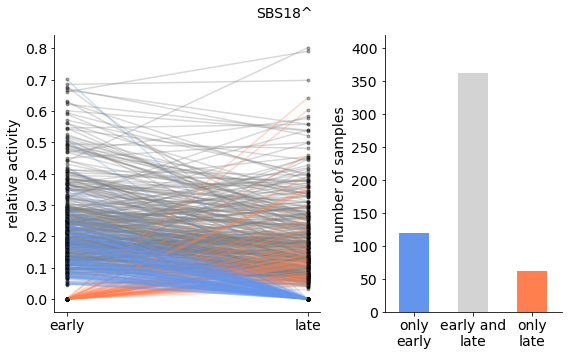

In [3]:
############### Figure 2a ###############

fig,ax = plt.subplots(1,2,figsize=(8,5),width_ratios=[3, 2])

sig = 'SBS288B'

curr_late = acts.loc[these_samples + '_late',sig] 
curr_early = acts.loc[these_samples + '_early',sig] 
curr_late.index = curr_late.index.str.split('_').str[0]
curr_early.index = curr_early.index.str.split('_').str[0]


curr_change = curr_late - curr_early
have_big_change_up = curr_change[curr_change>.06].index
have_big_change_down = curr_change[curr_change<-.06].index
dont_have_change = set(curr_late.index) - set(have_big_change_up) - set(have_big_change_down)


have_early = curr_early[curr_early>0].index
dont_have_early = curr_early[curr_early==0].index

have_late = curr_late[curr_late>0].index
dont_have_late = curr_late[curr_late==0].index

only_early = set(have_early) - set(have_late)
early_and_late = set(have_early)  & set(have_late)
only_late = set(have_late) - set(have_early)
neither = set(dont_have_early) & set(dont_have_late)



for sample in early_and_late:
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='grey',
            alpha=.3)
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='black',
             alpha=.3,marker='o',markersize=3,linewidth=0)
    


for sample in only_late:
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='coral',
            alpha=.3)
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='black',
             alpha=.3,marker='o',markersize=3,linewidth=0)
    
for sample in only_early:
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='cornflowerblue',
            alpha=.3)
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='black',
             alpha=.3,marker='o',markersize=3,linewidth=0)

ax[0].set_ylabel('relative activity')
    
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)



# add_stat_annotation(ax[0], data=acts, x='timing', y=sig,
#                     box_pairs=[("early", "late")],
#                     test='Wilcoxon', text_format='star', loc='inside', verbose=2)


for item in ([ax[0].title, ax[0].xaxis.label, ax[0].yaxis.label] +
             ax[0].get_xticklabels() + ax[0].get_yticklabels()):
    item.set_fontsize(14)
    
########################################################


have_early = curr_early[curr_early>0].index
dont_have_early = curr_early[curr_early==0].index

have_late = curr_late[curr_late>0].index
dont_have_late = curr_late[curr_late==0].index

only_early = set(have_early) - set(have_late)
early_and_late = set(have_early)  & set(have_late)
only_late = set(have_late) - set(have_early)


for_bar2 = pd.Series(index = ['only\nearly','early and\nlate','only\nlate'],
         data=[len(only_early),len(early_and_late),len(only_late)])

for_bar2.plot.bar(ax=ax[1],color=['cornflowerblue','lightgrey','coral'])



inearly = curr_early[curr_early>0].index
inlate = curr_late[curr_late>0].index

both = set(inearly) | set(inlate)

mean_early = curr_early.loc[both].mean()
mean_late = curr_late.loc[both].mean()


# pd.Series(index = ['early','late'],
#          data=[mean_early,mean_late]).plot.bar(color=['cornflowerblue','coral'],ax=ax[1])


inearly = curr_early[curr_early>0].index
inlate = curr_late[curr_late>0].index

both = set(inearly) | set(inlate)

mean_early = curr_early.loc[both].mean()
mean_late = curr_late.loc[both].mean()


# pd.Series(index = ['early','late'],
#          data=[mean_early,mean_late]).plot.bar(color=['cornflowerblue','coral'])

early_temp = curr_early.loc[both]
early_temp.name='value'
early_temp_df = pd.DataFrame(early_temp)
early_temp_df['time'] = 'early'


late_temp = curr_late.loc[both]
late_temp.name='value'
late_temp_df = pd.DataFrame(late_temp)
late_temp_df['time'] = 'late'
both_df = pd.concat([early_temp_df,late_temp_df])
# sns.boxplot(data = both_df,
#               x='time',y='value',color='grey',palette=['cornflowerblue','coral'])

statss = pd.Series([len(have_big_change_down),len(have_big_change_up)],
         index=['decreased','increased'])
#statss.plot.bar(ax=ax[1],color=['cornflowerblue','coral'])

ax[1].set_xlabel('')
ax[1].set_ylabel('')


ax[1].tick_params(axis='x', rotation=0)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# ax[1].set_xlabel('early \u2192 late')

ax[1].set_ylabel('number of samples')

ax[1].set_ylim(0,420)

for item in ([ax[1].title, ax[1].xaxis.label, ax[1].yaxis.label] +
             ax[1].get_xticklabels() + ax[1].get_yticklabels()):
    item.set_fontsize(14)
    
fig.suptitle('SBS18^',fontsize=14)

plt.tight_layout()

# plt.savefig('plots_for_paper/timing_B_V2.png',dpi=300)



# print out stats




from statsmodels.stats.contingency_tables import mcnemar

result = mcnemar([[len(have_early & have_late),len(have_early & dont_have_late)],
        [len(dont_have_early & have_late),len(dont_have_early & dont_have_late)]])

print(result.pvalue)

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/3125770750.py:96: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_early = curr_early.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/3125770750.py:97: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_late = curr_late.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/3125770750.py:109: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_early = curr_early.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_75416/3125770750.py:110: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mean_late = curr_late.loc[both].mean()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn

5.376542123418932e-25


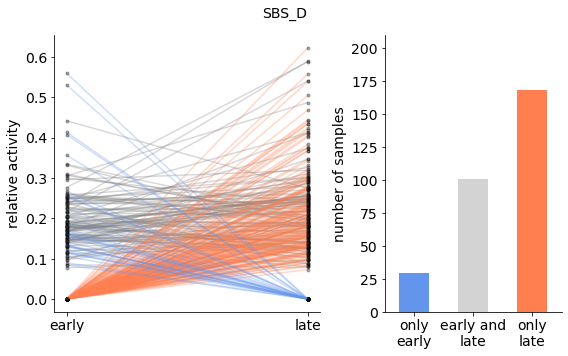

In [4]:
############### Figure 2b ###############

# make change plots

fig,ax = plt.subplots(1,2,figsize=(8,5),width_ratios=[3, 2])

sig = 'SBS288D'

curr_late = acts.loc[these_samples + '_late',sig] 
curr_early = acts.loc[these_samples + '_early',sig] 
curr_late.index = curr_late.index.str.split('_').str[0]
curr_early.index = curr_early.index.str.split('_').str[0]


curr_change = curr_late - curr_early
have_big_change_up = curr_change[curr_change>.06].index
have_big_change_down = curr_change[curr_change<-.06].index
dont_have_change = set(curr_late.index) - set(have_big_change_up) - set(have_big_change_down)


have_early = curr_early[curr_early>0].index
dont_have_early = curr_early[curr_early==0].index

have_late = curr_late[curr_late>0].index
dont_have_late = curr_late[curr_late==0].index

only_early = set(have_early) - set(have_late)
early_and_late = set(have_early)  & set(have_late)
only_late = set(have_late) - set(have_early)
neither = set(dont_have_early) & set(dont_have_late)



for sample in early_and_late:
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='grey',
            alpha=.3)
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='black',
             alpha=.3,marker='o',markersize=3,linewidth=0)
    


for sample in only_late:
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='coral',
            alpha=.3)
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='black',
             alpha=.3,marker='o',markersize=3,linewidth=0)
    
for sample in only_early:
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='cornflowerblue',
            alpha=.3)
    ax[0].plot(['early','late'],[curr_early.loc[sample],curr_late.loc[sample]],color='black',
             alpha=.3,marker='o',markersize=3,linewidth=0)

ax[0].set_ylabel('relative activity')
    
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)



# add_stat_annotation(ax[0], data=acts, x='timing', y=sig,
#                     box_pairs=[("early", "late")],
#                     test='Wilcoxon', text_format='star', loc='inside', verbose=2)


for item in ([ax[0].title, ax[0].xaxis.label, ax[0].yaxis.label] +
             ax[0].get_xticklabels() + ax[0].get_yticklabels()):
    item.set_fontsize(14)
    
########################################################


have_early = curr_early[curr_early>0].index
dont_have_early = curr_early[curr_early==0].index

have_late = curr_late[curr_late>0].index
dont_have_late = curr_late[curr_late==0].index

only_early = set(have_early) - set(have_late)
early_and_late = set(have_early)  & set(have_late)
only_late = set(have_late) - set(have_early)


for_bar2 = pd.Series(index = ['only\nearly','early and\nlate','only\nlate'],
         data=[len(only_early),len(early_and_late),len(only_late)])

for_bar2.plot.bar(ax=ax[1],color=['cornflowerblue','lightgrey','coral'])



inearly = curr_early[curr_early>0].index
inlate = curr_late[curr_late>0].index

both = set(inearly) | set(inlate)

mean_early = curr_early.loc[both].mean()
mean_late = curr_late.loc[both].mean()


# pd.Series(index = ['early','late'],
#          data=[mean_early,mean_late]).plot.bar(color=['cornflowerblue','coral'],ax=ax[1])


inearly = curr_early[curr_early>0].index
inlate = curr_late[curr_late>0].index

both = set(inearly) | set(inlate)

mean_early = curr_early.loc[both].mean()
mean_late = curr_late.loc[both].mean()


# pd.Series(index = ['early','late'],
#          data=[mean_early,mean_late]).plot.bar(color=['cornflowerblue','coral'])

early_temp = curr_early.loc[both]
early_temp.name='value'
early_temp_df = pd.DataFrame(early_temp)
early_temp_df['time'] = 'early'


late_temp = curr_late.loc[both]
late_temp.name='value'
late_temp_df = pd.DataFrame(late_temp)
late_temp_df['time'] = 'late'
both_df = pd.concat([early_temp_df,late_temp_df])
# sns.boxplot(data = both_df,
#               x='time',y='value',color='grey',palette=['cornflowerblue','coral'])

statss = pd.Series([len(have_big_change_down),len(have_big_change_up)],
         index=['decreased','increased'])
#statss.plot.bar(ax=ax[1],color=['cornflowerblue','coral'])

ax[1].set_xlabel('')
ax[1].set_ylabel('')


ax[1].tick_params(axis='x', rotation=0)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# ax[1].set_xlabel('early \u2192 late')

ax[1].set_ylabel('number of samples')

for item in ([ax[1].title, ax[1].xaxis.label, ax[1].yaxis.label] +
             ax[1].get_xticklabels() + ax[1].get_yticklabels()):
    item.set_fontsize(14)
    
fig.suptitle('SBS_D',fontsize=14)

plt.tight_layout()

ax[1].set_ylim(0,210)

# plt.savefig('plots_for_paper/timing_D_V2.png',dpi=300)



# print out stats




from statsmodels.stats.contingency_tables import mcnemar

result = mcnemar([[len(have_early & have_late),len(have_early & dont_have_late)],
        [len(dont_have_early & have_late),len(dont_have_early & dont_have_late)]])

print(result.pvalue)